# Capital Asset Pricing Model

El Capital Asset Pricing Model (CAPM) es un modelo de valoración de activos que permite estimar la rentabilidad esperada de un activo financiero en función del riesgo sistemático del mismo, donde la medida de riesgo sistématico es la Beta.

$$
E[R] = r_f + \beta (r_m - r_f)
$$

Importación de librerías.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from matplotlib import pyplot as plt

Definimos tickers de los activos a trabajar.

In [2]:
tickers = ['GFNORTEO.MX', 'ALSEA.MX', 'CEMEXCPO.MX', 'TLEVISACPO.MX','^MXX']

Descargamos los precios de cierre.

In [3]:
prices = yf.download(tickers, start='2022-01-01', end='2026-09-08')['Close']
prices

[*********************100%***********************]  5 of 5 completed


Ticker,ALSEA.MX,CEMEXCPO.MX,GFNORTEO.MX,TLEVISACPO.MX,^MXX
Date,,,,,
2022-01-03,38.152382,13.558764,88.685219,34.775066,52941.011719
2022-01-04,39.193596,13.480047,89.006844,34.990398,53016.781250
2022-01-05,40.024662,13.470207,89.551636,35.699181,53024.148438
2022-01-06,39.910030,13.243901,92.321617,36.102913,53055.308594
2022-01-07,41.295128,13.135669,97.132996,36.659172,53202.109375
...,...,...,...,...,...
2026-09-01,41.500000,17.830000,192.220001,8.950000,64514.250000
2026-09-02,41.840000,18.000000,196.610001,9.010000,64884.281250
2026-09-03,42.849998,18.450001,197.960007,9.040000,65436.160156


Calculamos rendimientos diarios.

In [4]:
rets = prices.pct_change().dropna()
rets

Ticker,ALSEA.MX,CEMEXCPO.MX,GFNORTEO.MX,TLEVISACPO.MX,^MXX
Date,,,,,
2022-01-04,0.027291,-0.005806,0.003627,0.006192,0.001431
2022-01-05,0.021204,-0.000730,0.006121,0.020256,0.000139
2022-01-06,-0.002864,-0.016800,0.030932,0.011309,0.000588
2022-01-07,0.034705,-0.008172,0.052115,0.015408,0.002767
2022-01-10,0.008096,-0.021723,-0.012434,-0.014684,-0.006886
...,...,...,...,...,...
2026-08-31,0.007292,-0.013994,0.011601,-0.002141,-0.000825
2026-09-01,0.001448,-0.026747,-0.002543,-0.039700,-0.014001
2026-09-02,0.008193,0.009534,0.022838,0.006704,0.005736


Calculamos matriz de covarianza. Esto para calcular la $\beta$ de cada activo, que es el riesgo de mercado de cada activo.

$$
\beta = \frac{\sigma_{x, m}}{\sigma_m^2}
$$

In [5]:
covar = rets.cov()
covar

Ticker,ALSEA.MX,CEMEXCPO.MX,GFNORTEO.MX,TLEVISACPO.MX,^MXX
Ticker,,,,,
ALSEA.MX,0.000352,0.000099,0.000099,0.000099,0.000075
CEMEXCPO.MX,0.000099,0.000484,0.000124,0.000184,0.000132
GFNORTEO.MX,0.000099,0.000124,0.000381,0.000097,0.000125
TLEVISACPO.MX,0.000099,0.000184,0.000097,0.000746,0.000108
^MXX,0.000075,0.000132,0.000125,0.000108,0.000100


Nos quedamos con la columna de `^MXX`, ya que esta contiene las covarianzas de cada activo con respecto a el mercado.

In [6]:
covs_vs_mxx = covar.loc['^MXX'] 
covs_vs_mxx

Ticker
ALSEA.MX         0.000075
CEMEXCPO.MX      0.000132
GFNORTEO.MX      0.000125
TLEVISACPO.MX    0.000108
^MXX             0.000100
Name: ^MXX, dtype: float64

Ahora la varianza del mercado.

In [7]:
mxx_var = covar.loc['^MXX', '^MXX']
mxx_var

np.float64(0.00010011097376815385)

Calculamos las $\beta_s$.

In [8]:
betas = covs_vs_mxx / mxx_var
betas

Ticker
ALSEA.MX         0.752220
CEMEXCPO.MX      1.314705
GFNORTEO.MX      1.248470
TLEVISACPO.MX    1.079510
^MXX             1.000000
Name: ^MXX, dtype: float64

Calculamos el rendimiento del mercado anualizado.

In [9]:
r_m = rets['^MXX'].mean() * 252
r_m

np.float64(0.056812086985860745)

Definimos la tasa libre de riesgo.

In [10]:
r_f = 0.05 # Promedio de la tasa de los últimos 5 años

Calculamos los rendimientos esperados según el CAPM.

In [11]:
E_R = r_f + betas * (r_m - r_f)
E_R * 100

Ticker
ALSEA.MX         5.512419
CEMEXCPO.MX      5.895588
GFNORTEO.MX      5.850469
TLEVISACPO.MX    5.735371
^MXX             5.681209
Name: ^MXX, dtype: float64

Preparamos un espacio para graficar.

In [ ]:
space_betas = np.arange(0, 2, 0.01) # Espacio de betas
space_betas

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

In [ ]:
space_E_R = r_f + space_betas * (r_m - r_f) # Espacio de rendimientos
space_E_R

array([0.05      , 0.05006812, 0.05013624, 0.05020436, 0.05027248,
       0.0503406 , 0.05040873, 0.05047685, 0.05054497, 0.05061309,
       0.05068121, 0.05074933, 0.05081745, 0.05088557, 0.05095369,
       0.05102181, 0.05108993, 0.05115805, 0.05122618, 0.0512943 ,
       0.05136242, 0.05143054, 0.05149866, 0.05156678, 0.0516349 ,
       0.05170302, 0.05177114, 0.05183926, 0.05190738, 0.05197551,
       0.05204363, 0.05211175, 0.05217987, 0.05224799, 0.05231611,
       0.05238423, 0.05245235, 0.05252047, 0.05258859, 0.05265671,
       0.05272483, 0.05279296, 0.05286108, 0.0529292 , 0.05299732,
       0.05306544, 0.05313356, 0.05320168, 0.0532698 , 0.05333792,
       0.05340604, 0.05347416, 0.05354229, 0.05361041, 0.05367853,
       0.05374665, 0.05381477, 0.05388289, 0.05395101, 0.05401913,
       0.05408725, 0.05415537, 0.05422349, 0.05429161, 0.05435974,
       0.05442786, 0.05449598, 0.0545641 , 0.05463222, 0.05470034,
       0.05476846, 0.05483658, 0.0549047 , 0.05497282, 0.05504

Graficamos.

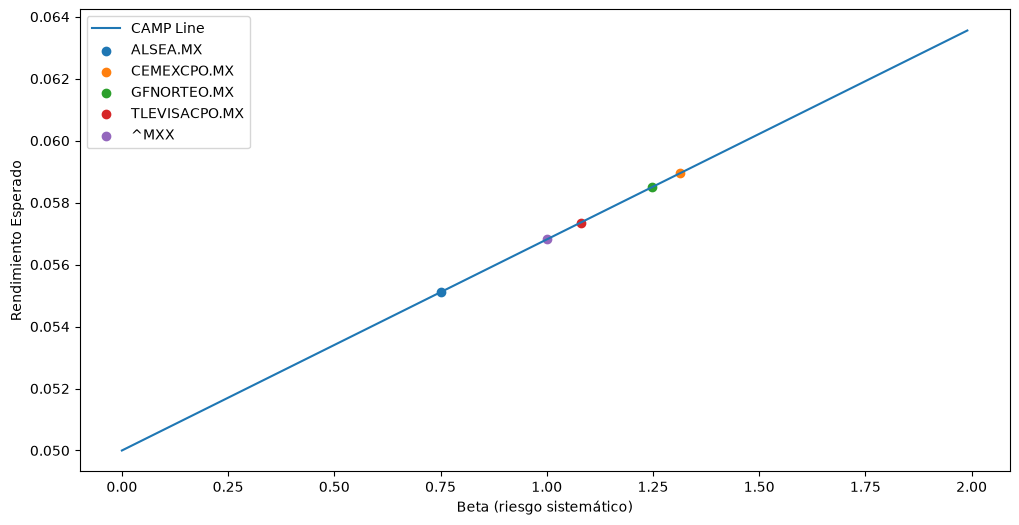

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(
    space_betas, 
    space_E_R, 
    label='CAMP Line'
)
for i in range(len(betas)):
    plt.scatter(
        betas.iloc[i],
        E_R.iloc[i], 
        label=prices.columns[i]
    )
plt.legend()
plt.xlabel('Beta (riesgo sistemático)')
plt.ylabel('Rendimiento Esperado')
plt.show()

Pero, ¿realmente estoy obteniendo el rendimiento real?

Ahora calculamos el rendimiento real.

In [15]:
rend_real = rets.mean() * 252
rend_real

Ticker
ALSEA.MX         0.068752
CEMEXCPO.MX      0.115876
GFNORTEO.MX      0.223519
TLEVISACPO.MX   -0.189733
^MXX             0.056812
dtype: float64

Graficamos los rendimientos reales contra los del CAPM.

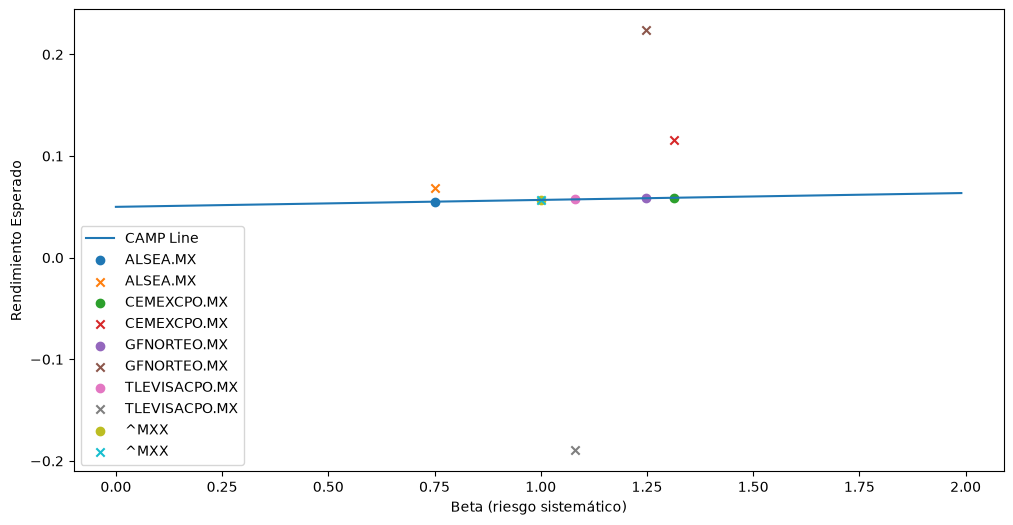

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(
    space_betas, 
    space_E_R,
    label='CAMP Line'
)
for i in range(len(betas)):
    plt.scatter(
        betas.iloc[i], 
        E_R.iloc[i], 
        label=prices.columns[i]
    )
    plt.scatter(
        betas.iloc[i], 
        rend_real.iloc[i], 
        label=prices.columns[i], 
        marker='x'
    )
plt.legend()
plt.xlabel('Beta (riesgo sistemático)')
plt.ylabel('Rendimiento Esperado')
plt.show()

El CAPM subestima todos los activos. 

Si mi activo tiene un rendimiento real por encima del CAPM significa que esta subvaluado, ya que lo que te paga es mayor a lo que se pricea. (Long) Compra

Y si está por debajo del CAPM, está sobrevalorado, ya que el activo te paga menos de a lo que se pricea. (Short) Venta